# Forward Replay: Compare forward vs backward vs k-swap

Loads replay_results.json from the synthetic seed sweep. Compares three algorithms across random N∈{8..12} instances in R²/R³ over a gamma grid.

## Setup — load results

In [ ]:
%matplotlib inline
import os, json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# works whether the notebook runs from notebooks/ or the repo root
ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
RES = os.path.join(ROOT, "results", "forward_beats_backward")

# Use a small on-disk cache to avoid reparsing the large JSON every run.
p_json = os.path.join(RES, "replay_results.json")
p_parquet = os.path.join(RES, "replay_results.parquet")
p_pkl = os.path.join(RES, "replay_results.pkl")

start = time.time()
if os.path.exists(p_parquet):
    # fast path: read parquet (if available)
    df = pd.read_parquet(p_parquet)
    # load config from JSON (small) if present, else empty
    config = json.load(open(p_json)) if os.path.exists(p_json) else {}
    config = config.get("config", config) if isinstance(config, dict) else {}
    loaded_from = 'parquet'
elif os.path.exists(p_pkl):
    df = pd.read_pickle(p_pkl)
    config = json.load(open(p_json)) if os.path.exists(p_json) else {}
    config = config.get("config", config) if isinstance(config, dict) else {}
    loaded_from = 'pickle'
else:
    # fallback: parse JSON once and write a cache (pickle preferred for portability)
    payload = json.load(open(p_json))
    records = payload["records"]
    config = payload.get("config", {})
    df = pd.DataFrame(records)
    try:
        # try parquet first (if fast engine installed)
        df.to_parquet(p_parquet)
        loaded_from = 'json->parquet'
    except Exception:
        df.to_pickle(p_pkl)
        loaded_from = 'json->pickle'

configs = ["n_forward", "n_backward", "n_kswap"]
config_names = {"n_forward": "forward", "n_backward": "backward", "n_kswap": "k-swap"}

elapsed = time.time() - start
print(f"Loaded dataframe ({loaded_from}) in {elapsed:.3f}s — {len(df)} rows")
print(f"Config: {config}")
print(df.head())

Loaded 100000 records
Config: {'n_seeds': 400, 'n_range': [8, 9, 10, 11, 12], 'dims': [2, 3], 'n_gamma': 25, 'metric': 'mean_abs', 'kswap_k': 2}
   dim  N  seed     gamma  gamma_over_scale  n_forward  n_backward  n_kswap  \
0    2  8     0  0.034246          0.020000          7           5        5   
1    2  8     0  0.075627          0.044167          7           5        5   
2    2  8     0  0.117008          0.068333          6           4        4   
3    2  8     0  0.158389          0.092500          6           4        4   
4    2  8     0  0.199769          0.116667          6           4        4   

            forward_kept    backward_kept       kswap_kept     E_forward  \
0  [0, 1, 2, 3, 4, 5, 7]  [1, 3, 4, 5, 7]  [1, 3, 4, 5, 7]  6.765405e-09   
1  [0, 1, 2, 3, 4, 5, 7]  [1, 3, 4, 5, 7]  [1, 3, 4, 5, 7]  6.765405e-09   
2     [0, 1, 2, 4, 5, 7]     [1, 4, 5, 7]     [1, 4, 5, 7]  8.054213e-02   
3     [0, 1, 2, 4, 5, 7]     [1, 4, 5, 7]     [1, 4, 5, 7]  8.054213e-02   


## Aggregate results by config and gamma

In [2]:
# Fast aggregation via pandas groupby
gammas = np.sort(df["gamma"].unique())
print(f"Unique gammas: {len(gammas)}")
print(f"Gamma range: {gammas.min():.4f} to {gammas.max():.4f}")

summary = {}
for cfg_key in configs:
    grouped = df.groupby("gamma")[cfg_key].agg(["mean", "std", "min", "max", "count"]).reindex(gammas)
    summary[cfg_key] = {
        float(g): {
            "mean_size": float(grouped.loc[g, "mean"]),
            "std_size": float(0.0 if np.isnan(grouped.loc[g, "std"]) else grouped.loc[g, "std"]),
            "min_size": int(grouped.loc[g, "min"]),
            "max_size": int(grouped.loc[g, "max"]),
            "n_instances": int(grouped.loc[g, "count"]),
        }
        for g in gammas
    }

# precompute winners once for all gammas
df["best_cfg_idx"] = df[configs].to_numpy().argmin(axis=1)
df["best_cfg"] = df["best_cfg_idx"].map(dict(enumerate(configs)))
wins_df = (df.groupby(["gamma", "best_cfg"]).size().unstack(fill_value=0).reindex(index=gammas, fill_value=0))

print("\nSummary keys:", list(summary.keys()))
print(f"Example (forward, first gamma): {summary['n_forward'][float(gammas[0])]} ")
print(wins_df.head())

Unique gammas: 100000
Gamma range: 0.0172 to 2.0524

Summary keys: ['n_forward', 'n_backward', 'n_kswap']
Example (forward, first gamma): {'mean_size': 6.0, 'std_size': 0.0, 'min_size': 6, 'max_size': 6, 'n_instances': 1} 
best_cfg  n_backward  n_forward  n_kswap
gamma                                   
0.017245           1          0        0
0.017331           1          0        0
0.018826           1          0        0
0.019490           1          0        0
0.019696           1          0        0


## Plot 1 — |S| vs γ (all configs, mean ± std)

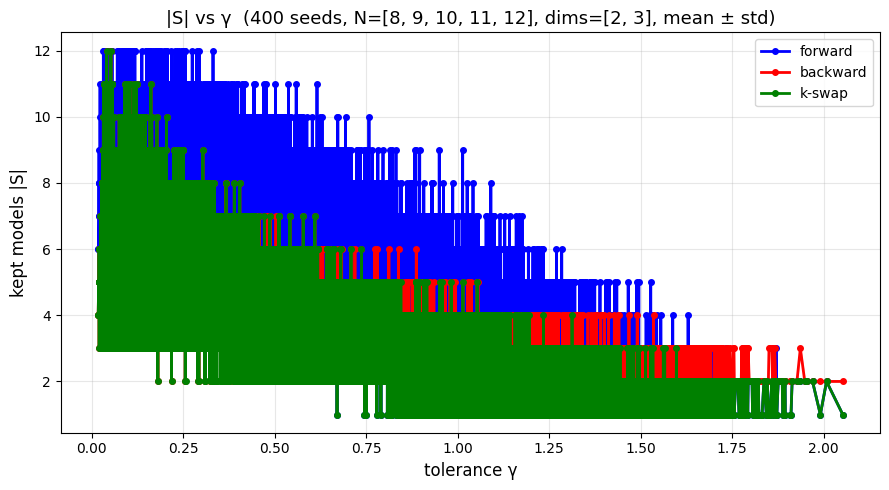

In [3]:
x = np.array(gammas)
colors = {"n_forward": "blue", "n_backward": "red", "n_kswap": "green"}

fig, ax = plt.subplots(figsize=(9, 5))
for cfg_key in configs:
    m = np.array([summary[cfg_key][g]["mean_size"] for g in gammas])
    s = np.array([summary[cfg_key][g]["std_size"] for g in gammas])
    label = config_names[cfg_key]
    ax.plot(x, m, "-o", color=colors[cfg_key], lw=2, ms=4, label=label)
    ax.fill_between(x, m - s, m + s, color=colors[cfg_key], alpha=0.15)

ax.set_xlabel("tolerance γ", fontsize=12)
ax.set_ylabel("kept models |S|", fontsize=12)
ax.set_title(f"|S| vs γ  ({config['n_seeds']} seeds, N={config['n_range']}, dims={config['dims']}, mean ± std)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Plot 2 — Grouped bars: models kept per config × gamma

In [ ]:
ng, nc = len(gammas), len(configs)
w = 0.8 / nc
base = np.arange(ng)

fig, ax = plt.subplots(figsize=(12, 5))
for i, cfg_key in enumerate(configs):
    m = np.array([summary[cfg_key][g]["mean_size"] for g in gammas])
    s = np.array([summary[cfg_key][g]["std_size"] for g in gammas])
    label = config_names[cfg_key]
    ax.bar(base + i * w, m, w, yerr=s, capsize=2, color=colors[cfg_key],
           label=label, error_kw={"elinewidth": 0.7})

ax.set_xticks(base + 0.4 - w / 2)
ax.set_xticklabels([f"{g:.2f}" for g in gammas], rotation=45, fontsize=9)
ax.set_xlabel("tolerance γ", fontsize=12)
ax.set_ylabel("kept models |S|  (mean, error = std)", fontsize=12)
ax.set_title(f"Models kept per config  ({config['n_seeds']} random seeds)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Plot 3 — best configs (subset of algorithms)

Focus on the strongest algorithms at higher γ, matching the style of the reference notebook.

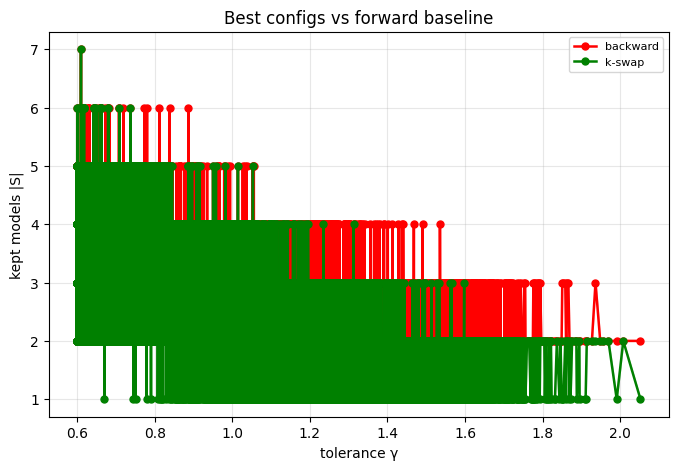

In [4]:
best = ["n_backward", "n_kswap"]
mask = x >= np.median(x)
fig, ax = plt.subplots(figsize=(8, 5))
for c in best:
    m, s = np.array([summary[c][float(g)]["mean_size"] for g in gammas]), np.array([summary[c][float(g)]["std_size"] for g in gammas])
    ax.plot(x[mask], m[mask], "-o", color=colors[c], lw=1.8, ms=5, label=config_names[c])
    ax.fill_between(x[mask], (m - s)[mask], (m + s)[mask], color=colors[c], alpha=0.15)
ax.set_xlabel("tolerance γ")
ax.set_ylabel("kept models |S|")
ax.set_title("Best configs vs forward baseline")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

## Plot 4 — gap to best configuration (0 = best at that γ)

This mirrors the reference notebook’s final gap plot, but uses the best replay configuration instead of an exact optimum.

In [ ]:
best_mean = np.array([min(summary[c][float(g)]["mean_size"] for c in configs) for g in gammas])
fig, ax = plt.subplots(figsize=(9, 4.5))
ng, nc = len(gammas), len(configs)
w = 0.8 / nc
base = np.arange(ng)
for i, c in enumerate(configs):
    gaps = np.array([summary[c][float(g)]["mean_size"] for g in gammas]) - best_mean
    ax.bar(base + i * w, gaps, w, color=colors[c], label=config_names[c])
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(base + 0.4 - w / 2)
ax.set_xticklabels([f"{g:.2f}" for g in gammas], rotation=45, fontsize=9)
ax.set_xlabel("tolerance γ")
ax.set_ylabel("mean |S| − best mean |S|")
ax.set_title("Gap to best config  (0 = best at that γ)")
ax.legend(fontsize=8, ncol=2)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

/var/folders/7g/tj_ljgc97_59_f7500cwr81r0000gn/T/ipykernel_56683/773525313.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/Users/lucijajurkovic/Desktop/EPCRC/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
